**The Challenge**



The sinking of the Titanic is one of the most infamous shipwrecks in history.
On April 15, 1912, during her maiden voyage, the widely considered “unsinkable”
RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t
enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224
passengers and crew.
While there was some element of luck involved in surviving, it seems some groups
of people were more likely to survive than others.
In this challenge, we ask you to build a predictive model that answers the
question:" what sorts of people were more likely to survive? "using passenger
data (ie name, age, gender, socio-economic class, etc)

**Import the libraries**
**As the first step all neccessary libraries will be imported.**

In [ ]:
# Mute the warnings
import warnings
warnings.filterwarnings('ignore')
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd
# visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
# machine learning
from sklearn.linear_model import LogisticRegression, RidgeClassifierCV
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
# Styling:
cust_palt = [
    '#111d5e', '#c70039', '#f37121', '#ffbd69', '#ffc93c'
]
plt.style.use('ggplot')

**Getting to know your data**



**As usual the first step is to get to know the data; how many samples, what are the**
**attributes, what are the missing data**

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
combine = [train_df, test_df]

In [ ]:
print(train_df.columns.values)

['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']


**Categorical features:** Survived, Sex, and Embarked. Ordinal: Pclass.
**numerical features**:Continous: Age, Fare. Discrete: SibSp, Parch.
**mixed features**:Ticket is a mix of numeric and alphanumeric data types. Cabin is
alphanumeric.
**Name feature** may contain errors or typos as there are several ways used to
describe a name including titles, round brackets, and quotes used for
alternative or short names.

In [ ]:
# preview the data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# preview the data
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


**Which features contain blank, null or empty values?**
These will require correcting
Cabin > Age > Embarked features contain a number of null values in that
order for the training dataset.
Cabin > Age are incomplete in case of test dataset

In [ ]:
#Shows the count of missing values for each column
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**What are the data types for various features?**
Helping us during converting goal.
Seven features are **integer or floats.** Six in case of **test dataset.**
Five features are **strings** (object)

In [ ]:
train_df.info()
print('_'*40)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passenger

What is the distribution of numerical feature values
across the samples?
This helps us determine, among other early insights, how representative is the
training dataset of the actual problem domain.
**numerical features:**
Continous: Age, Fare. Discrete: SibSp, Parch.

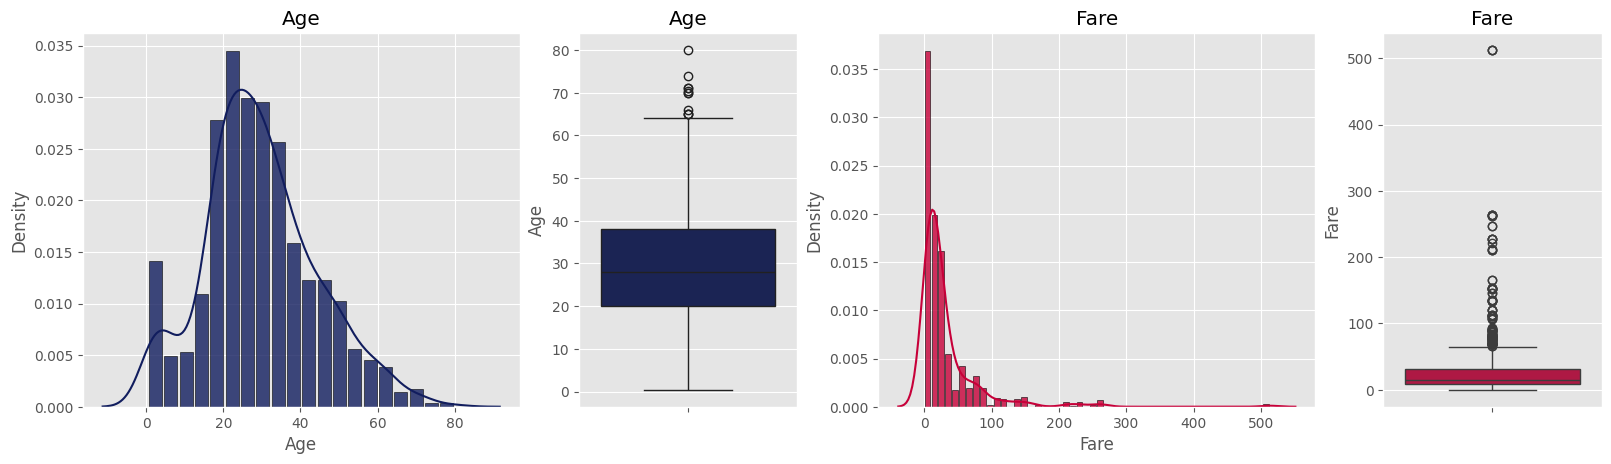

In [ ]:
# Displaying numeric distribution:
fig = plt.figure(constrained_layout=True, figsize=(16, 12))
grid = gridspec.GridSpec(ncols=6, nrows=3, figure=fig)
ax1 = fig.add_subplot(grid[0, :2])
ax1.set_title('Age')
sns.distplot(train_df['Age'],
                 hist_kws={
                 'rwidth': 0.85,
                 'edgecolor': 'black',
                 'alpha': 0.8},
                 color=cust_palt[0])
ax15 = fig.add_subplot(grid[0, 2:3])
ax15.set_title('Age')
sns.boxplot(train_df['Age'], orient='v', color=cust_palt[0])
ax2 = fig.add_subplot(grid[0, 3:5])
ax2.set_title('Fare')
sns.distplot(train_df['Fare'],
                 hist_kws={
                 'rwidth': 0.85,
                 'edgecolor': 'black',
                 'alpha': 0.8},
                 color=cust_palt[1])
ax25 = fig.add_subplot(grid[0, 5:])
ax25.set_title('Fare')
sns.boxplot(train_df['Fare'], orient='v', color=cust_palt[1])
plt.show()

**What is the distribution of categorical features?**


In [ ]:
train_df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


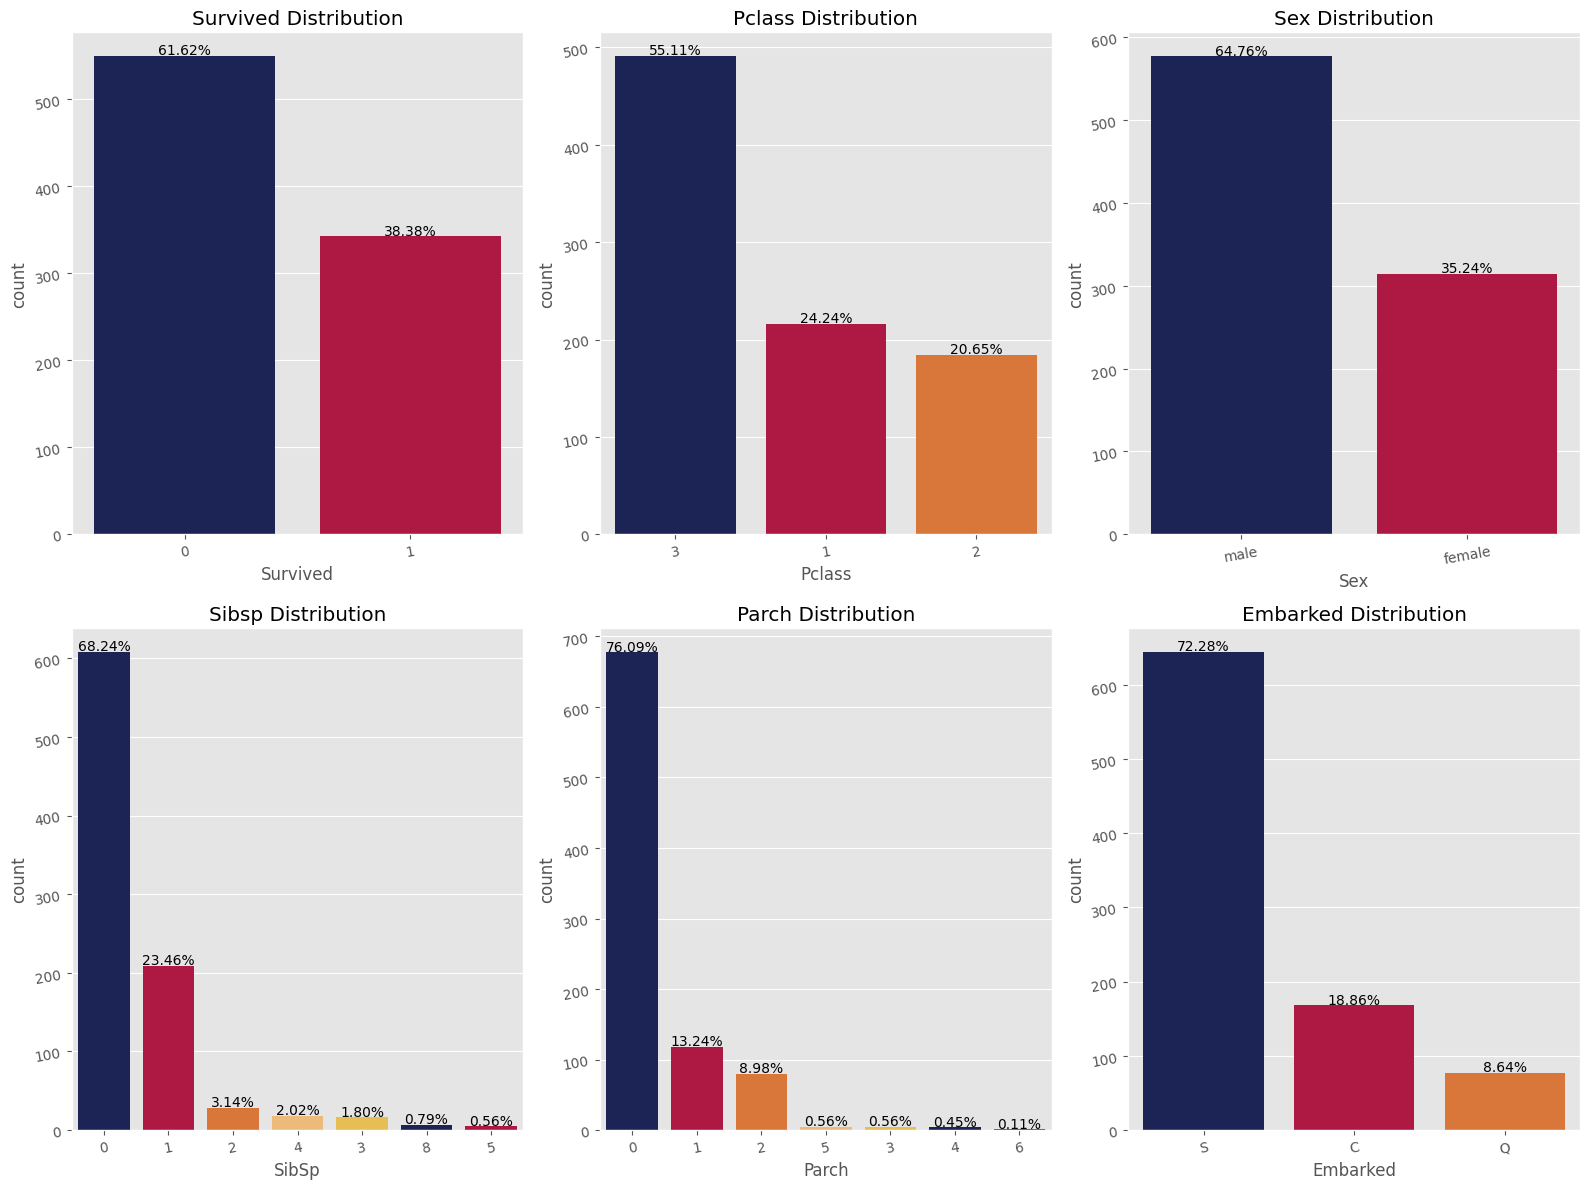

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# FIX: Filter columns by nunique() and pull out the actual string NAMES (.index)
categorical = train_df.columns[train_df.nunique() <= 10].tolist()
continuous = train_df.columns[train_df.nunique() > 10].tolist()
def ctg_dist(df, cols, hue=None, rows=2, columns=3):
    '''A function for displaying categorical distribution'''

    fig, axes = plt.subplots(rows, columns, figsize=(16, 12))
    axes = axes.flatten()

    # Loop over the list of column names directly
    for i, j in zip(cols, axes):
        sns.countplot(x=i,
                    data=df,
                    palette=cust_palt, # Make sure cust_palt is defined earlier
                    hue=hue,
                    ax=j,
                    order=df[i].value_counts().index)
        j.tick_params(labelrotation=10)

        total = float(len(df[i]))
        j.set_title(f'{str(i).capitalize()} Distribution')

        for p in j.patches:
            height = p.get_height()
            # Added a tiny safety check in case height is null/zero
            if height > 0:
                j.text(p.get_x() + p.get_width() / 2.,
                        height + 2,
                        '{:1.2f}%'.format((height / total) * 100),
                        ha='center')

    plt.tight_layout()
    plt.show()

# Now this will correctly display ONLY your categorical columns!
ctg_dist(train_df, categorical)

What does “analyze by pivoting features” mean?
Pivoting means looking at two pieces of information about passengers (like their ticket class and whether they survived) and seeing how they relate to each other. It’s like making a simple table that shows, for example, “How many first-class passengers survived vs. how many died?”

They only did this for features that:

Have no missing values (every passenger has that information).

Are categories (like male/female), ordered groups (like 1st, 2nd, 3rd class), or small whole numbers (like number of siblings on board).

In [ ]:
# Sort by the mean survival rate (optional)
train_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived')

,Pclass,Survived
2,3,0.242363
1,2,0.472826
0,1,0.629630


In [ ]:
train_df[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived')

,Sex,Survived
1,male,0.188908
0,female,0.742038


In [ ]:
train_df[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived')

,SibSp,Survived
6,8,0.000000
5,5,0.000000
4,4,0.166667
3,3,0.250000
0,0,0.345395
2,2,0.464286
1,1,0.535885


In [ ]:
train_df[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived')

,Parch,Survived
6,6,0.000000
4,4,0.000000
5,5,0.200000
0,0,0.343658
2,2,0.500000
1,1,0.550847
3,3,0.600000


**Analyze by visualizing data**
Now we can continue confirming some of our assumptions using visualizations
for analyzing the data.
Correlating numerical features
age and survived

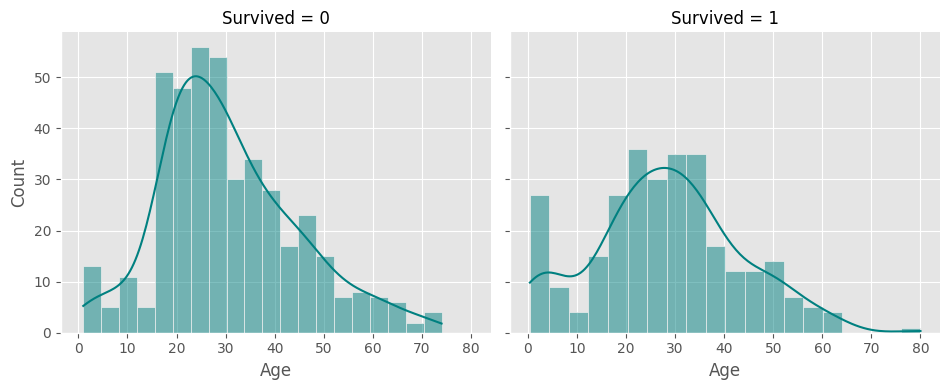

In [ ]:
g = sns.FacetGrid(train_df, col='Survived', height=4, aspect=1.2)
# Using sns.histplot allows you to easily add a smooth KDE line
g.map(sns.histplot, 'Age', bins=20, kde=True, color='teal')
plt.show()

**Observations:**
Infants (Age <=4) had high survival rate.
Oldest passengers (Age = 80) survived.
Large number of 15-25 year olds did not survive
Most passengers are in 15-35 age range.
**Decisions:**
This simple analysis confirms our assumptions as decisions for subsequent
workflow stages

**Correlating numerical and ordinal features**
We can combine multiple features for identifying correlations using a single plot.
This can be done with numerical and categorical features which have numeric
values.
**Survived,Pclass,Age**

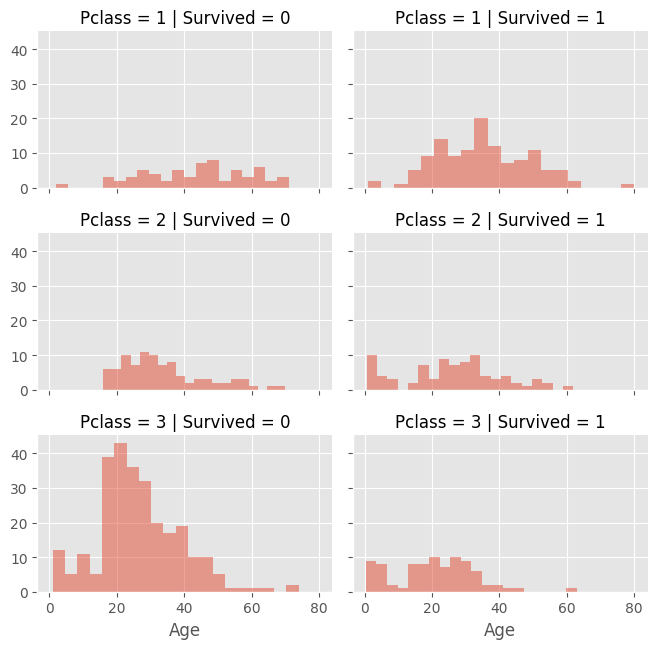

In [ ]:
grid = sns.FacetGrid(train_df, col='Survived', row='Pclass', height=2.2, aspect=1.5)
grid.map(plt.hist, 'Age', alpha=0.5, bins=20)
grid.add_legend()
plt.show()

**Observations:**
Pclass=3 had most passengers, however most did not survive. Confirms our
classifying assumption #2.
Infant passengers in Pclass=2 and Pclass=3 mostly survived. Further qualifies
our classifying assumption #2.
Most passengers in Pclass=1 survived. Confirms our classifying assumption
#3.

Pclass varies in terms of Age distribution of passengers.
**Decisions**
Consider Pclass for model training.

**Correlating categorical features**
Now we can correlate categorical features with our solution goal.
**Pclass,Survived,Sex,Embarked**

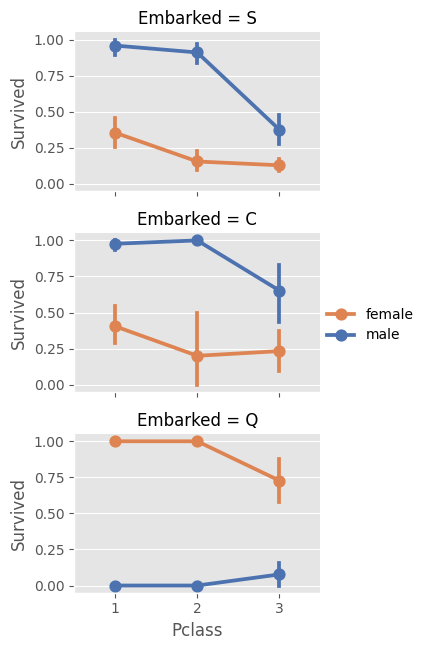

In [ ]:
grid = sns.FacetGrid(train_df, row='Embarked', height=2.2, aspect=1.6)
grid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', palette='deep')
grid.add_legend()
plt.show()

**Observations:**
Female passengers had much better survival rate than males. Confirms
classifying (#1).
Exception in Embarked=C where males had higher survival rate. This could be
a correlation between Pclass and Embarked and in turn Pclass and Survived,
not necessarily direct correlation between Embarked and Survived.
Males had better survival rate in Pclass=3 when compared with Pclass=2 for C
and Q ports. Completing (#2).
Ports of embarkation have varying survival rates for Pclass=3 and among
male passengers. Correlating (#1).
**Decisions:**
Add Sex feature to model training.
Complete and add Embarked feature to model training

**Correlating categorical and numerical features**
We can consider correlating Embarked (Categorical non
numeric), Sex (Categorical non-numeric), Fare (Numeric continuous), with
Survived (Categorical numeric).

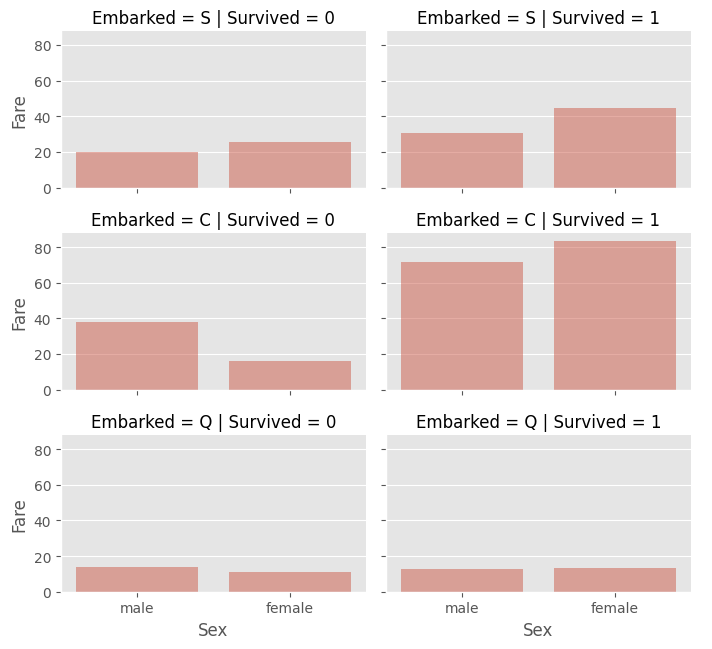

In [ ]:
grid = sns.FacetGrid(train_df, row='Embarked', col='Survived', height=2.2, aspect=1.6)
grid.map(sns.barplot, 'Sex', 'Fare', alpha=.5, ci=None)
grid.add_legend()
plt.show()

**Observations:**
Higher fare paying passengers had better survival. Confirms our assumption
for creating (#4) fare ranges.
Port of embarkation correlates with survival rates. Confirms correlating (#1)
and completing (#2)
**Decisions:**
Consider banding Fare feature

**Wrangle data**
**Correcting by dropping features**
This is a good starting goal to execute. By dropping features we are dealing with
fewer data points. Speeds up our notebook and eases the analysis. Based on our assumptions and decisions we want to drop the Cabin (correcting #2) and Ticket
(correcting #1) features.
Note that where applicable we perform operations on both training and testing
datasets together to stay consistent.

In [ ]:
# Assuming train_df and test_df are already defined
combine = [train_df, test_df]
print("Before", train_df.shape, test_df.shape, combine[0].shape, combine[1].shape)

train_df = train_df.drop(['Ticket', 'Cabin'], axis=1)
test_df = test_df.drop(['Ticket', 'Cabin'], axis=1)
combine = [train_df, test_df]

print("After", train_df.shape, test_df.shape, combine[0].shape, combine[1].shape)

Before (891, 12) (418, 11) (891, 12) (418, 11)
After (891, 10) (418, 9) (891, 10) (418, 9)


**Creating new feature extracting from existing**
We want to analyze if** Name feature **can be engineered to extract **titles** and test
correlation between titles and survival, before dropping Name and PassengerId
features.

In [ ]:
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

Sex vs Title
Title vs survived

In [ ]:
pd.crosstab(train_df['Title'], train_df['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


We can replace many titles with a more common name or classify them as Rare.
Groups the data by unique values in the Title column (e.g., 'Mr', 'Mrs', 'Miss', 'Rare').

In [ ]:
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess', 'Jonkheer', 'Capt', 'Don', 'Major', 'Sir'], 'Rare')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

In [ ]:
train_df[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,Col,0.500000
1,Dr,0.428571
2,Master,0.575000
3,Miss,0.702703
4,Mr,0.156673
5,Mrs,0.793651
6,Rare,0.500000
7,Rev,0.000000


**We can convert the categorical titles to ordinal**

In [ ]:
title_mapping = {"Col": 1, "Dr": 2, "Lady": 3, "Master": 4, "Miss": 5, "Mr": 6,}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,6.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,5.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,6.0


we can safely drop the Name feature from training and testing datasets. We
also do not need the PassengerId feature in the training dataset.

In [ ]:
train_df = train_df.drop(['Name', 'PassengerId'], axis=1)
test_df = test_df.drop(['Name'], axis=1)
combine = [train_df, test_df]
train_df.shape, test_df.shape

((891, 9), (418, 9))

Converting a categorical feature
Now we can convert features which contain strings to numerical values. This is
required by most model algorithms. Doing so will also help us in achieving the
feature completing goal.
Let us start by converting Sex feature to a new feature called Gender where
female=1 and male=0.

In [ ]:
for dataset in combine:
    dataset['Sex'] = dataset['Sex'].map({'female': 1, 'male': 0}).astype(int)
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22.0,1,0,7.2500,S,6.0
1,1,1,1,38.0,1,0,71.2833,C,0.0
2,1,3,1,26.0,0,0,7.9250,S,5.0
3,1,1,1,35.0,1,0,53.1000,S,0.0
4,0,3,0,35.0,0,0,8.0500,S,6.0


Completing a numerical continuous feature
S
S
7
6
Now we should start estimating and completing features with missing or null
values. We will first do this for the Age feature.
We can consider three methods to complete a numerical continuous feature.
A simple way is to generate random numbers between mean and standard
deviation.
More accurate way of guessing missing values is to use other correlated
features. In our case we note correlation among Age, Gender, and Pclass.
Guess Age values using median values for Age across sets of Pclass and
Gender feature combinations. So, median Age for Pclass=1 and Gender=0,
Pclass=1 and Gender=1, and so on...
Combine methods 1 and 2. So instead of guessing age values based on
median, use random numbers between mean and standard deviation, based
on sets of Pclass and Gender combinations.Method 1 and 3 will introduce random noise into our models. The results from
multiple executions might vary. We will prefer method 2

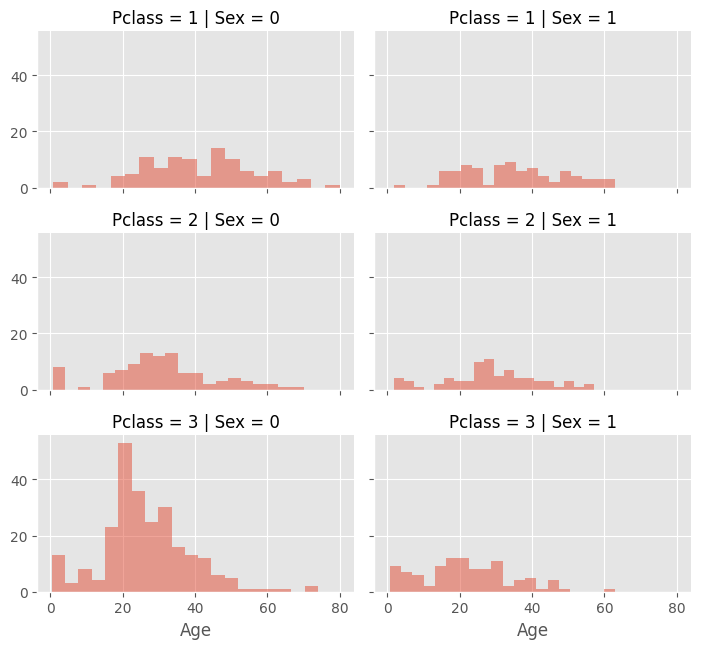

In [ ]:
grid = sns.FacetGrid(train_df, row='Pclass', col='Sex', height=2.2, aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend()
plt.show()

In [ ]:
#Let us start by preparing an empty array to contain guessed Age values based on Pclass x Gender combinations
guess_ages = np.zeros((2,3))
guess_ages



array([[0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
# Initialize a 2x3 array to store guessed ages
guess_ages = np.zeros((2, 3))

for dataset in combine:
    for i in range(0, 2):          # Sex: 0=male, 1=female
        for j in range(0, 3):      # Pclass: 0->1, 1->2, 2->3
            # Get median Age for this sex and pclass (ignore NaNs)
            guess_df = dataset[(dataset['Sex'] == i) & (dataset['Pclass'] == j+1)]['Age'].dropna()
            age_guess = guess_df.median()
            # Round to nearest 0.5
            guess_ages[i, j] = int(age_guess / 0.5 + 0.5) * 0.5

    # Fill missing ages using the precomputed guesses
    for i in range(0, 2):
        for j in range(0, 3):
            dataset.loc[(dataset.Age.isnull()) & (dataset.Sex == i) & (dataset.Pclass == j+1), 'Age'] = guess_ages[i, j]

    dataset['Age'] = dataset['Age'].astype(int)

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22,1,0,7.2500,S,6.0
1,1,1,1,38,1,0,71.2833,C,0.0
2,1,3,1,26,0,0,7.9250,S,5.0
3,1,1,1,35,1,0,53.1000,S,0.0
4,0,3,0,35,0,0,8.0500,S,6.0


In [ ]:
#Let us create Age bands and determine correlations with Survived
train_df['AgeBand'] = pd.cut(train_df['Age'], 5)
train_df[['AgeBand', 'Survived']].groupby(['AgeBand'], as_index=False).mean().sort_values(by='AgeBand')

,AgeBand,Survived
0,"(-0.08, 16.0]",0.550000
1,"(16.0, 32.0]",0.337374
2,"(32.0, 48.0]",0.412037
3,"(48.0, 64.0]",0.434783
4,"(64.0, 80.0]",0.090909


In [ ]:
for dataset in combine:
    dataset.loc[ dataset['Age'] <= 16, 'Age'] = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age'] = 4

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,AgeBand
0,0,3,0,1,1,0,7.2500,S,6.0,"(16.0, 32.0]"
1,1,1,1,2,1,0,71.2833,C,0.0,"(32.0, 48.0]"
2,1,3,1,1,0,0,7.9250,S,5.0,"(16.0, 32.0]"
3,1,1,1,2,1,0,53.1000,S,0.0,"(32.0, 48.0]"
4,0,3,0,2,0,0,8.0500,S,6.0,"(32.0, 48.0]"


Create new feature combining existing features
We can create a new feature for FamilySize which combines Parch and SibSp. This
will enable us to drop Parch and SibSp from our datasets.

In [ ]:
for dataset in combine:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
train_df[['FamilySize', 'Survived']].groupby(['FamilySize'], as_index=False).mean()

,FamilySize,Survived
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


In [ ]:
#We can create another feature called IsAlone.
for dataset in combine:
    dataset['IsAlone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1
train_df[['IsAlone', 'Survived']].groupby(['IsAlone'], as_index=False).mean()

,IsAlone,Survived
0,0,0.505650
1,1,0.303538


In [ ]:
train_df = train_df.drop(['Parch',], axis=1)
test_df = test_df.drop(['Parch'], axis=1)
combine = [train_df, test_df]
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked,Title,AgeBand,FamilySize,IsAlone
0,0,3,0,1,1,7.2500,S,6.0,"(16.0, 32.0]",2,0
1,1,1,1,2,1,71.2833,C,0.0,"(32.0, 48.0]",2,0
2,1,3,1,1,0,7.9250,S,5.0,"(16.0, 32.0]",1,1
3,1,1,1,2,1,53.1000,S,0.0,"(32.0, 48.0]",2,0
4,0,3,0,2,0,8.0500,S,6.0,"(32.0, 48.0]",1,1


In [ ]:
#We can also create an artificial feature combining Pclass and Age.
for dataset in combine:
    dataset['Age*Class'] = dataset.Age * dataset.Pclass
    train_df.loc[:, ['Age*Class', 'Age', 'Pclass']].head(10)

Completing a categorical feature
Embarked feature takes S, Q, C values based on port of embarkation. Our training
dataset has two missing values. We simply fill these with the most common
occurance.

In [ ]:
freq_port = train_df.Embarked.dropna().mode()[0]
freq_port

'S'

In [ ]:
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].fillna(freq_port)
train_df[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


Converting categorical feature to numeric
We can now convert the EmbarkedFill feature by creating a new numeric Port
feature

In [ ]:
freq_port = train_df['Embarked'].mode()[0]
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].fillna(freq_port)
    dataset['Embarked'] = dataset['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked,Title,AgeBand,FamilySize,IsAlone,Age*Class
0,0,3,0,1,1,7.2500,0,6.0,"(16.0, 32.0]",2,0,3
1,1,1,1,2,1,71.2833,1,0.0,"(32.0, 48.0]",2,0,2
2,1,3,1,1,0,7.9250,0,5.0,"(16.0, 32.0]",1,1,3
3,1,1,1,2,1,53.1000,0,0.0,"(32.0, 48.0]",2,0,2
4,0,3,0,2,0,8.0500,0,6.0,"(32.0, 48.0]",1,1,6


Quick completing and converting a numeric
feature
We can now complete the Fare feature for single missing value in test dataset
using mode to get the value that occurs most frequently for this feature. We do
this in a single line of code.
Note that we are not creating an intermediate new feature or doing any further
analysis for correlation to guess missing feature as we are replacing only a single
value. The completion goal achieves desired requirement for model algorithm to
operate on non-null values.
We may also want round off the fare to two decimals as it represents currency.

In [ ]:
test_df['Fare'].fillna(test_df['Fare'].dropna().median(), inplace=True)
test_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Fare,Embarked,Title,FamilySize,IsAlone,Age*Class
0,892,3,0,2,0,7.8292,2,6.0,1,1,6
1,893,3,1,2,1,7.0000,0,0.0,2,0,6
2,894,2,0,3,0,9.6875,2,6.0,1,1,6
3,895,3,0,1,0,8.6625,0,6.0,1,1,3
4,896,3,1,1,1,12.2875,0,0.0,3,0,3


In [ ]:
train_df['FareBand'] = pd.qcut(train_df['Fare'], 4)
train_df[['FareBand', 'Survived']].groupby(['FareBand'], as_index=False).mean()

,FareBand,Survived
0,"(-0.001, 7.91]",0.197309
1,"(7.91, 14.454]",0.303571
2,"(14.454, 31.0]",0.454955
3,"(31.0, 512.329]",0.581081


In [ ]:
for dataset in combine:
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare']
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare']
    dataset.loc[ dataset['Fare'] > 31, 'Fare'] = 3
    dataset['Fare'] = dataset['Fare'].astype(int)
train_df = train_df.drop(['FareBand'], axis=1)
combine = [train_df, test_df]

train_df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked,Title,AgeBand,FamilySize,IsAlone,Age*Class
0,0,3,0,1,1,0,0,6.0,"(16.0, 32.0]",2,0,3
1,1,1,1,2,1,3,1,0.0,"(32.0, 48.0]",2,0,2
2,1,3,1,1,0,7,0,5.0,"(16.0, 32.0]",1,1,3
3,1,1,1,2,1,3,0,0.0,"(32.0, 48.0]",2,0,2
4,0,3,0,2,0,8,0,6.0,"(32.0, 48.0]",1,1,6
5,0,3,0,1,0,8,2,6.0,"(16.0, 32.0]",1,1,3
6,0,1,0,3,0,3,0,6.0,"(48.0, 64.0]",1,1,3
7,0,3,0,0,3,21,0,4.0,"(-0.08, 16.0]",5,0,0
8,1,3,1,1,0,11,0,0.0,"(16.0, 32.0]",3,0,3
9,1,2,1,0,1,30,1,0.0,"(-0.08, 16.0]",2,0,0


In [ ]:
# Test dataset
test_df.head(10)

,PassengerId,Pclass,Sex,Age,SibSp,Fare,Embarked,Title,FamilySize,IsAlone,Age*Class
0,892,3,0,2,0,0,2,6.0,1,1,6
1,893,3,1,2,1,0,0,0.0,2,0,6
2,894,2,0,3,0,9,2,6.0,1,1,6
3,895,3,0,1,0,8,0,6.0,1,1,3
4,896,3,1,1,1,12,0,0.0,3,0,3
5,897,3,0,0,0,9,0,6.0,1,1,0
6,898,3,1,1,0,0,2,5.0,1,1,3
7,899,2,0,1,1,29,0,6.0,3,0,2
8,900,3,1,1,0,0,1,0.0,1,1,3
9,901,3,0,1,2,24,0,6.0,3,0,3


 Our problem is a classification and regression problem.
We want to identify relationship between output (Survived or not) with other
variables or features (Gender, Age, Port...). We are also perfoming a category of
machine learning which is called supervised learning as we are training our model
with a given dataset. With these two criteria - Supervised Learning plus
Classification and Regression, we can narrow down our choice of models to a few.

In [ ]:
X_train = train_df.drop("Survived", axis=1)
Y_train = train_df["Survived"]
X_test  = test_df.drop("PassengerId", axis=1).copy()
X_train.head(10)

,Pclass,Sex,Age,SibSp,Fare,Embarked,Title,AgeBand,FamilySize,IsAlone,Age*Class
0,3,0,1,1,0,0,6.0,"(16.0, 32.0]",2,0,3
1,1,1,2,1,3,1,0.0,"(32.0, 48.0]",2,0,2
2,3,1,1,0,7,0,5.0,"(16.0, 32.0]",1,1,3
3,1,1,2,1,3,0,0.0,"(32.0, 48.0]",2,0,2
4,3,0,2,0,8,0,6.0,"(32.0, 48.0]",1,1,6
5,3,0,1,0,8,2,6.0,"(16.0, 32.0]",1,1,3
6,1,0,3,0,3,0,6.0,"(48.0, 64.0]",1,1,3
7,3,0,0,3,21,0,4.0,"(-0.08, 16.0]",5,0,0
8,3,1,1,0,11,0,0.0,"(16.0, 32.0]",3,0,3
9,2,1,0,1,30,1,0.0,"(-0.08, 16.0]",2,0,0


In [ ]:
Y_train.head(5)

,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
X_test.head(5)

,Pclass,Sex,Age,SibSp,Fare,Embarked,Title,FamilySize,IsAlone,Age*Class
0,3,0,2,0,0,2,6.0,1,1,6
1,3,1,2,1,0,0,0.0,2,0,6
2,2,0,3,0,9,2,6.0,1,1,6
3,3,0,1,0,8,0,6.0,1,1,3
4,3,1,1,1,12,0,0.0,3,0,3


**model training**

Logistic regression tries to predict whether a passenger survived (1) or not (0).
It does this by looking at each feature (like Sex, Age, Pclass, etc.) and giving it a coefficient (a number).

Positive coefficient → as that feature increases, the chance of survival goes up.

Negative coefficient → as that feature increases, the chance of survival goes down.

Larger absolute value (ignoring the sign) → the feature has a stronger effect.
we remove age band because for calculation we need a cloumn having just numerical values.

In [ ]:
# Ensure 'AgeBand' is dropped from both feature sets
X_train = X_train.drop(columns=['AgeBand'], errors='ignore')
X_test = X_test.drop(columns=['AgeBand'], errors='ignore')

# Now run logistic regression
logreg = LogisticRegression()
logreg.fit(X_train, Y_train)
Y_pred = logreg.predict(X_test)
acc_log = round(logreg.score(X_train, Y_train) * 100, 2)
print(acc_log)

80.13


In [ ]:
coeff_df = pd.DataFrame(X_train.columns.delete(0))
coeff_df.columns = ['Feature']
coeff_df["Correlation"] = pd.Series(logreg.coef_[0])
coeff_df.sort_values(by='Correlation', ascending=False)

,Feature,Correlation
1,Age,2.143662
5,Title,0.231187
4,Embarked,0.001970
6,FamilySize,-0.190207
7,IsAlone,-0.233303
2,SibSp,-0.277809
3,Fare,-0.278309
8,Age*Class,-0.519301
0,Sex,-0.823737


What is SVM?
Imagine you have two groups of points on a piece of paper (survived vs. did not survive).
SVM tries to draw a straight line (or a curved boundary) that separates the two groups as clearly as possible.
It picks the line that has the widest gap between the closest points of each group.
That’s why it’s sometimes called a “maximum margin” classifier.

In [ ]:
# Support Vector Machines
svc = SVC()
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)
acc_svc = round(svc.score(X_train, Y_train) * 100, 2)
acc_svc

81.59

What is k‑NN?
This is even simpler:

To predict if a passenger survived, the model looks at the k most similar passengers in the training data (neighbors).

It checks what happened to those neighbors.

Then it takes a majority vote: if most of the neighbors survived, the model predicts “survived”. If most died, it predicts “died”.

Here, they used n_neighbors = 3, so it looks at the 3 most similar passengers.

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, Y_train)
Y_pred = knn.predict(X_test)
acc_knn = round(knn.score(X_train, Y_train) * 100, 2)
acc_knn

86.2

How it works:
It uses probability math (Bayes’ theorem) with a “naive” assumption: it treats every feature (like age, sex, fare) as if they are completely independent of each other. That’s rarely true in real life (e.g., age and fare are somewhat related), but the model is fast and simple.

Why lowest accuracy?
The independence assumption is too strong for Titanic data. Features like Pclass and Fare are correlated, so the model makes weaker predictions.

Plain English: It guesses based on probabilities, assuming everything is unrelated – which hurts accuracy.



In [ ]:
# Gaussian Naive Bayes
gaussian = GaussianNB()
gaussian.fit(X_train, Y_train)
Y_pred = gaussian.predict(X_test)
acc_gaussian = round(gaussian.score(X_train, Y_train) * 100, 2)
acc_gaussian

79.01

The perceptron is an algorithm for supervised learning of binary classifiers
(functions that can decide whether an input, represented by a vector of numbers,
belongs to some specific class or not). It is a type of linear classifier, i.e. a
classification algorithm that makes its predictions based on a linear predictor
function combining a set of weights with the feature vector. The algorithm allows
for online learning, in that it processes elements in the training set one at a time.


In [ ]:
# Perceptron
perceptron = Perceptron()
perceptron.fit(X_train, Y_train)
Y_pred = perceptron.predict(X_test)
acc_perceptron = round(perceptron.score(X_train, Y_train) * 100, 2)
acc_perceptron

69.02

How it works:
It asks a series of yes/no questions about the passenger (e.g., “Is female?” → “Is Pclass = 1?” → “Is age > 30?”) until it reaches a final decision: survived or died. The tree branches out like a flowchart.

Why so high?
Decision trees can capture complex, non-linear relationships. They don’t assume a straight line; they create rules that split the data into smaller groups.

Caveat: Such high training accuracy might mean overfitting – the tree memorized the training data too well and might not perform as well on unseen test data.

Plain English: A set of “if-else” questions that leads to a survival guess. Very flexible, but can overthink and memorize.

In [ ]:
# Decision Tree
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, Y_train)
Y_pred = decision_tree.predict(X_test)
acc_decision_tree = round(decision_tree.score(X_train, Y_train) * 100, 2)
acc_decision_tree

91.47

How it works:
It builds many decision trees (100 of them), each trained on a random subset of the data and random subset of features. Then it averages their predictions (majority vote). This is called “ensemble learning.”

Why it’s popular:
By averaging many trees, it reduces overfitting while keeping the high accuracy of decision trees. It’s more robust and generalizes better to new data.

Why chosen for submission?
It gives the highest confidence score (tied with single decision tree but more reliable). The tutorial picks this model’s output for the competition.

Plain English: A committee of 100 decision trees voting on the answer. It’s smarter and less likely to make silly mistakes than a single tree.

In [ ]:
# Random Forest
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, Y_train)
Y_pred = random_forest.predict(X_test)
random_forest.score(X_train, Y_train)
acc_random_forest = round(random_forest.score(X_train, Y_train) * 100, 2)
acc_random_forest

91.47

How it works:
Another ensemble method, but instead of building trees independently, it builds them one after another. Each new tree focuses on correcting the mistakes made by the previous trees. Trees are shallow (weak learners) but together they form a strong model.

Performance:
Very good (85.86%), but slightly lower than random forest on this training set. In many competitions, gradient boosting (e.g., XGBoost, LightGBM) often wins, but here random forest did slightly better.

Plain English: A team of learners where each new member learns from the errors of the previous ones. They improve step by step.

In [ ]:
# Gradient Boosting
grad_boost = GradientBoostingClassifier(n_estimators = 100)
grad_boost.fit(X_train, Y_train)
Y_pred = grad_boost.predict(X_test)
grad_boost.score(X_train, Y_train)
acc_grad_boost = round(grad_boost.score(X_train, Y_train) * 100, 2)
acc_grad_boost

87.88

How it works:
A linear model like logistic regression or perceptron, but with regularization – it adds a penalty to prevent extreme coefficient values. “CV” means it automatically tunes the strength of that penalty using cross-validation.

Performance:
Decent (almost 80%), but still behind tree-based models because Titanic data has non-linear patterns that linear models miss.

Plain English: A straight-line classifier that avoids jumping to extreme conclusions. Works okay, but can’t handle complicated relationships.

In [ ]:
# RidgeClassifierCV
Ridge= RidgeClassifierCV()
Ridge.fit(X_train, Y_train)
Y_pred = Ridge.predict(X_test)
acc_Ridge= round(Ridge.score(X_train, Y_train) * 100, 2)
acc_Ridge

79.91

Model evaluation
We can now rank our evaluation of all the models to choose the best one for our
problem.

In [ ]:
import pandas as pd

# Create DataFrame with all models and their accuracy scores
models = pd.DataFrame({
    'Model': ['Support Vector Machines', 'KNN', 'Logistic Regression',
              'Gaussian Naive Bayes', 'Perceptron', 'Decision Tree',
              'Random Forest', 'Gradient Boosting', 'RidgeClassifierCV'],
    'AccuracyScore': [acc_svc, acc_knn, acc_log, acc_gaussian,
                      acc_perceptron, acc_decision_tree,
                      acc_random_forest, acc_grad_boost, acc_Ridge]
})

# Sort by accuracy descending
models_sorted = models.sort_values(by='AccuracyScore', ascending=False)
print(models_sorted)

                     Model  AccuracyScore
6            Random Forest          91.47
5            Decision Tree          91.47
7        Gradient Boosting          87.88
1                      KNN          86.20
0  Support Vector Machines          81.59
2      Logistic Regression          80.13
8        RidgeClassifierCV          79.91
3     Gaussian Naive Bayes          79.01
4               Perceptron          69.02


Optimizing Model
1. Split the training data
They took the original training set and split it into two parts:

Development set (80%) – used to train models and tune settings.

Evaluation set (20%) – kept hidden to test how well the model performs on unseen data.

This prevents cheating (overfitting).

2. Grid search on Random Forest
They tried many combinations of settings (hyperparameters) for Random Forest – like how many trees, how deep they can go, etc.
The computer found the best combination, which gave 84.41% accuracy on the development set.
When tested on the evaluation set (unseen data), it dropped to 81.56% – a small drop, which is normal.

3. Grid search on Gradient Boosting
Same idea, but for Gradient Boosting. Best development accuracy = 83.99%, evaluation accuracy = 81.56% (same as Random Forest).
What are hyperparameters?
Think of a model (like Random Forest) as a recipe for baking a cake.
The recipe has settings you can adjust:

How many trees? (like how many layers in the cake)

How deep can each tree go? (like baking temperature)

How many samples per leaf? (like how much flour)

These settings are hyperparameters. You choose them before the model learns.
They are NOT learned from the data – you decide them.

Plain English: Hyperparameters are the “dials” or “knobs” you turn to control how the model works.

What is grid search?
Instead of guessing the best dial settings, grid search tries many combinations automatically.

Imagine you have 3 dials:

Dial A: can be 100, 200, or 300

Dial B: can be “gini” or “entropy”

Dial C: can be 2, 4, or 6

Grid search tries every combination:

(100, gini, 2)

(100, gini, 4)

(100, gini, 6)

(100, entropy, 2)

… and so on.

For each combination, it trains the model and checks its performance using cross‑validation. Then it picks the best one.

Plain English: Grid search is like trying every possible setting on your radio to find the clearest station – but the computer does it automatically.

In [80]:
# Split the training set into a development and an evaluation sets
from sklearn.model_selection import train_test_split
X_dev, X_eval, y_dev, y_eval = train_test_split(X_train,
                                                Y_train,
                                                test_size=0.2,
                                                random_state=42)

In [81]:
# 1. Random Forest
import time
dict_clf = {}
paramgrid = {
    'n_estimators':      [100, 150, 200, 250, 300, 400, 500],
    'criterion':         ['gini', 'entropy'],
    'max_features':      ['auto', 'log2'],
    'min_samples_leaf':  list(range(2, 8))
}
GS = GridSearchCV(RandomForestClassifier(random_state=77),
                  paramgrid,
                  cv=4)
# Fit the data and record time taking to train
t0 = time.time()
GS.fit(X_dev, y_dev)
t = time.time() - t0
# Store best parameters, score and estimator
best_clf = GS.best_estimator_
best_params = GS.best_params_
best_score = GS.best_score_
name = 'RF'
best_clf.fit(X_dev, y_dev)
acc_eval = accuracy_score(y_eval, best_clf.predict(X_eval))
dict_clf[name] = {
    'best_par': best_params,
    'best_clf': best_clf,
    'best_score': best_score,
    'score_eval': acc_eval,
    'fit_time': t,
}
acc_eval

0.8100558659217877

In [82]:
# 2. GradientBoosting
paramgrid = {
    'n_estimators':      [100, 150, 200, 250, 300, 400, 500],
    'max_features':      ['auto', 'log2'],
    'min_samples_leaf':  list(range(2, 7)),
    'loss' :             ['deviance', 'exponential'],
    'learning_rate':     [0.025, 0.05, 0.075, 0.1],
}
GS = GridSearchCV(GradientBoostingClassifier(random_state=77),
                  paramgrid,
                  cv=4)
# Fit the data and record time taking to train
t0 = time.time()
GS.fit(X_dev, y_dev)
t = time.time() - t0
# Store best parameters, score and estimator
best_clf = GS.best_estimator_
best_params = GS.best_params_
best_score = GS.best_score_
name = 'GB'
best_clf.fit(X_dev, y_dev)
acc_eval = accuracy_score(y_eval, best_clf.predict(X_eval))
dict_clf[name] = {
    'best_par': best_params,
    'best_clf': best_clf,
    'best_score': best_score,
    'score_eval': acc_eval,
    'fit_time': t,
}
acc_eval

0.8212290502793296

we used grid search to find the best hyperparameters


In [84]:
for clf in dict_clf.keys():
    print("{0} classifier:\n\t- Best score = {1:.2%}".format(clf, dict_clf[clf]['best_score']))
    print("\t- Score on evaluation set = {0:.2%}".format(dict_clf[clf]['score_eval']))
    print("\t- Fitting time = {0:.1f} min".format(round(dict_clf[clf]['fit_time'] / 60, 1)))
    print("\t- Best parameters:")
    for par in sorted(dict_clf[clf]['best_par'].keys()):
        print("\t\t* {0}: {1}".format(par, dict_clf[clf]['best_par'][par]))

RF classifier:
	- Best score = 83.99%
	- Score on evaluation set = 81.01%
	- Fitting time = 2.4 min
	- Best parameters:
		* criterion: gini
		* max_features: log2
		* min_samples_leaf: 7
		* n_estimators: 400
GB classifier:
	- Best score = 83.29%
	- Score on evaluation set = 82.12%
	- Fitting time = 3.0 min
	- Best parameters:
		* learning_rate: 0.025
		* loss: exponential
		* max_features: log2
		* min_samples_leaf: 3
		* n_estimators: 200


Ensembling
Now we include a soft voting of the top 3-5 (stacking) trying to improve further
more the results
4. Ensembling (Voting Classifier)
They took the best models (Random Forest, Gradient Boosting, plus KNN, SVM, and Decision Tree) and let them vote on each prediction.
The majority wins. This is like asking five experts instead of one.

They got a final prediction array (0 = died, 1 = survived) for the test set.

The problem
Even after all this optimization and voting, the final accuracy on the test set (Kaggle competition) was only about 78%.
That’s not terrible, but it’s not great either – top competitors get over 80%.

The tutorial admits: “This is not a good result at all.”

Why didn’t it get higher?
Because they already used the best model settings (hyperparameters) and even combined multiple models.
The issue isn’t the model anymore – it’s the features themselves (the input data).

They need better features – for example:

Extracting titles from names (Mr, Mrs, Miss, Master) – they already did this.

Creating family size, alone flag – done.

Maybe grouping fares into categories, or creating a “cabin letter” feature.

Interaction terms (Age*Pclass – done).

But to reach ~82% accuracy, they need more creative feature engineering – like guessing family relationships from surnames, or using cabin information, or creating a “deck” feature.

In [85]:
from sklearn.ensemble import VotingClassifier
estimators = [('RF', dict_clf['RF']['best_clf']),
('GB', dict_clf['GB']['best_clf']),
('KNN', knn), ('svc', svc), ('trees', decision_tree)]
# Instantiate the VotingClassifier using hard voting
voter = VotingClassifier(estimators=estimators, voting='hard')
voter.fit(X_train, Y_train)
Y_pred = voter.predict(X_test).astype(int)
Y_pred

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,